# Solver Segment Efficiency — Fixed Acceptance (ε = 2 mrad)

New-data remake of the classical/quantum **solver segment-efficiency** 2×2
figure, reading the decoupled `qtrk_store` **metrics view**.
**Nothing is re-solved here** — the Condor solves are read back and the segment
metrics are the recomputed view.

**Headline operating point = wp99 (high-efficiency working point).** Per solver,
per config, the activation threshold τ is placed just below the 1 % quantile of the
*true* segment amplitudes, so ~99 % of the true segments stay active and we quote the
false rate paid (the LHCb-style picture: recover all true segments, kill the false
ones). The fixed γ-aware absolute cut τ = δ/(δ+γ)+0.10 (= 0.35 at γ=3) is the
*low-false-rate* choice; for the 1BQF it chops the reshaped outer true band and pins
efficiency at the artificial ~75 % plateau ("the cut, not lost physics"). It is kept
as the **faded diagnostic** in panels i & ii so the contrast that motivated the 1BQF
stays visible.

**Data:** fixed ε = 2 mrad (`eps_provenance='set'`), σ_scatt = 1e-4, σ_res = 0,
φ_max = 0.2, step kernel.  Sweep: n_trk ∈ {10 … 1000}, γ ∈ {1, 2, 3},
hit inefficiency ∈ {0, 1 %}.

**2×2 panels (headline = wp99; faded = fixed τ):**
| Panel | Quantity | Definition |
|---|---|---|
| i)  | segment efficiency | N_true,active / N_true,all |
| ii) | segment false rate | N_false,active / N_active |
| iii)| total segment pairs | N_true,all and N_false,all vs n_trk (threshold-free) |
| iv) | active segment pairs | N_true,active and N_false,active vs n_trk (wp99) |

**Headline:** γ = 3, δ = 1, for **classical** and **1BQF**, at the 1 % hit-drop point.
**Companion:** γ ∈ {1, 2, 3} overlay of the two key panels.

In [1]:
import sys
sys.path.insert(0, "/data/bfys/gscriven/Quantum_Track_Reconstruction/Toy_Characterisation/Segment_level_studies")
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seg_store as S

plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                      "axes.grid": True, "grid.alpha": 0.3})
print("fixed acceptance ε =", S.EPS_FIXED, "rad (2 mrad)")
print("thresholds:  γ=1 -> τ=%.3f   γ=2 -> τ=%.3f   γ=3 -> τ=%.3f"
      % (S.threshold(1), S.threshold(2), S.threshold(3)))

OUT = Path(S.__file__).resolve().parent / "outputs" / "solver_segment_efficiency"
OUT.mkdir(parents=True, exist_ok=True)

fixed acceptance ε = 0.002 rad (2 mrad)
thresholds:  γ=1 -> τ=0.600   γ=2 -> τ=0.433   γ=3 -> τ=0.350


In [2]:
# ---- load the recomputed metrics view (fixed-ε only) ----------------------
M = S.fixed_eps_metrics()
READY = len(M) > 0
if not READY:
    print("[FLAG] metrics view has no fixed-ε (ε=2 mrad) rows yet.")
    print("       build_metrics.py is still running; it writes metrics.csv at the end.")
    print("       Re-run this notebook once it lands — every figure below will fill in.")
else:
    print(f"fixed-ε metrics rows: {len(M)}")
    inv = (M.groupby(["solver", "gamma", "hit_ineff"])["n_trk"]
             .agg(points="nunique", solves="count"))
    print(inv.to_string())

fixed-ε metrics rows: 1988
                           points  solves
solver    gamma hit_ineff                
classical 1.0   0.00           13     205
                0.01           13     205
          2.0   0.00           13     205
                0.01           13     205
          3.0   0.00           13     205
                0.01           13     205
qsvt      1.0   0.00           13      69
                0.01           13      69
          2.0   0.00           13      69
                0.01           13      69
          3.0   0.00           13     115
                0.01           13     115
quantum   1.0   0.00            8      24
                0.01            8      24
          2.0   0.00            8      24
                0.01            8      24
          3.0   0.00           11      78
                0.01           11      78


In [3]:
# ---- the shared 2×2 plotter (matches the original §-style figure) ---------
# CLASSICAL stays at the fixed γ-aware cut (τ=0.35 at γ=3), its operating point.
# The 1BQF (quantum) HEADLINE is the efficiency-first wp99 working point (τ holds
# ~99% of the true segments); the fixed τ=0.35 1BQF curve is kept FADED in panels
# i & ii as the diagnostic that produced the "~75% plateau" (the cut, not lost
# physics).  Pass wp_headline=True for the 1BQF, False (default) for classical.
C_EFF, C_FR = "#1b7837", "#c51b7d"
C_TRUE, C_FALSE = "#2166ac", "#d6604d"
C_FIX = "#f0a6c8"   # faded pink = fixed-τ diagnostic (1BQF only)

def plot_2x2(d, title, stem, wp_headline=False):
    """d = S.agg_by_ntrk(...) dict; draws + saves the 2×2 figure.

    wp_headline=True (1BQF): panels i/ii lead with wp99 + a faded fixed-τ curve,
    panel iv uses the wp99 active counts.  False (classical): fixed-τ only.
    """
    if not d:
        print(f"[FLAG] no data for: {title}  — skipped (config absent in store).")
        return
    tc = d["tc"]
    wp = wp_headline and "se_wp_m" in d
    fig, ax = plt.subplots(2, 2, figsize=(12, 10))

    a = ax[0, 0]
    if wp:
        a.errorbar(tc, d["se_m"], yerr=d["se_e"], fmt="s:", color=C_FIX,
                   capsize=3, mec="k", mew=0.4, zorder=2, label="fixed τ=0.35")
        a.errorbar(tc, d["se_wp_m"], yerr=d["se_wp_e"], fmt="o-", color=C_FR,
                   capsize=4, mec="k", mew=0.7, zorder=3, label="wp99 (eff≥99%)")
        a.legend(loc="lower left", fontsize=9)
        allv = np.concatenate([d["se_wp_m"], d["se_m"]])
    else:
        a.errorbar(tc, d["se_m"], yerr=d["se_e"], fmt="o-", color=C_FR,
                   capsize=4, mec="k", mew=0.7, zorder=3)
        allv = d["se_m"]
    a.axhline(100, color="gray", ls="--", lw=1.0, alpha=0.7)
    lo = max(0, np.floor(np.nanmin(allv)) - 2)
    a.set_ylim(lo, 100.8)
    a.set_ylabel("Segment efficiency (%)")
    a.set_title(r"i) Segment efficiency $N_{\rm true\,act}/N_{\rm true\,all}$",
                fontweight="bold")
    a.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))

    a = ax[0, 1]
    if wp:
        a.errorbar(tc, d["fr_m"], yerr=d["fr_e"], fmt="s:", color=C_FIX,
                   capsize=3, mec="k", mew=0.4, zorder=2, label="fixed τ=0.35")
        a.errorbar(tc, d["fr_wp_m"], yerr=d["fr_wp_e"], fmt="s-", color=C_FR,
                   capsize=4, mec="k", mew=0.7, zorder=3, label="wp99 (eff≥99%)")
        a.legend(loc="upper left", fontsize=9)
    else:
        a.errorbar(tc, d["fr_m"], yerr=d["fr_e"], fmt="s-", color=C_FR,
                   capsize=4, mec="k", mew=0.7, zorder=3)
    a.set_ylabel("Segment false rate (%)")
    a.set_title(r"ii) Segment false rate $N_{\rm false\,act}/N_{\rm active}$",
                fontweight="bold")
    a.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g%%"))

    a = ax[1, 0]
    a.errorbar(tc, d["ntm"], yerr=d["ntse"], fmt="o-", color=C_TRUE,
               capsize=3, mec="k", mew=0.7, label="True segments", zorder=3)
    a.errorbar(tc, d["nfm"], yerr=d["nfse"], fmt="s-", color=C_FALSE,
               capsize=3, mec="k", mew=0.7, label="False segments", zorder=3)
    a.set_yscale("log"); a.set_ylabel("Number of segment pairs")
    a.set_title("iii) Segment-pair counts", fontweight="bold")
    a.legend(loc="upper left", fontsize=10)

    a = ax[1, 1]
    tam = d.get("tam_wp", d["tam"]) if wp else d["tam"]
    tase = d.get("tase_wp", d["tase"]) if wp else d["tase"]
    fam_a = d.get("fam_wp", d["fam"]) if wp else d["fam"]
    fase_a = d.get("fase_wp", d["fase"]) if wp else d["fase"]
    fa = np.where(fam_a > 0, fam_a, 0.5)
    fae = np.where(fam_a > 0, fase_a, 0.0)
    a.errorbar(tc, tam, yerr=tase, fmt="o-", color=C_TRUE,
               capsize=3, mec="k", mew=0.7, label="True active", zorder=3)
    a.errorbar(tc, fa, yerr=fae, fmt="s-", color=C_FALSE,
               capsize=3, mec="k", mew=0.7, label="False active", zorder=3)
    a.set_yscale("log"); a.set_ylim(0.1, None)
    a.set_ylabel("Number of active segments")
    a.set_title("iv) Active segment pairs" + (" (wp99)" if wp else ""),
                fontweight="bold")
    a.legend(loc="lower right", fontsize=10)

    for x in ax.flat:
        x.set_xlabel("Number of tracks")
        x.tick_params(which="both", direction="in", top=True, right=True)
    for x in ax[1, :]:
        x.set_xscale("log")
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    for ext, dpi in (("pdf", 600), ("png", 300)):
        fig.savefig(OUT / f"{stem}.{ext}", dpi=dpi, bbox_inches="tight",
                    facecolor="white")
    plt.show()
    print("saved", stem, "(reps/point >=", d.get("n_reps"), ")")

## Headline — γ = 3 (the original operating point)

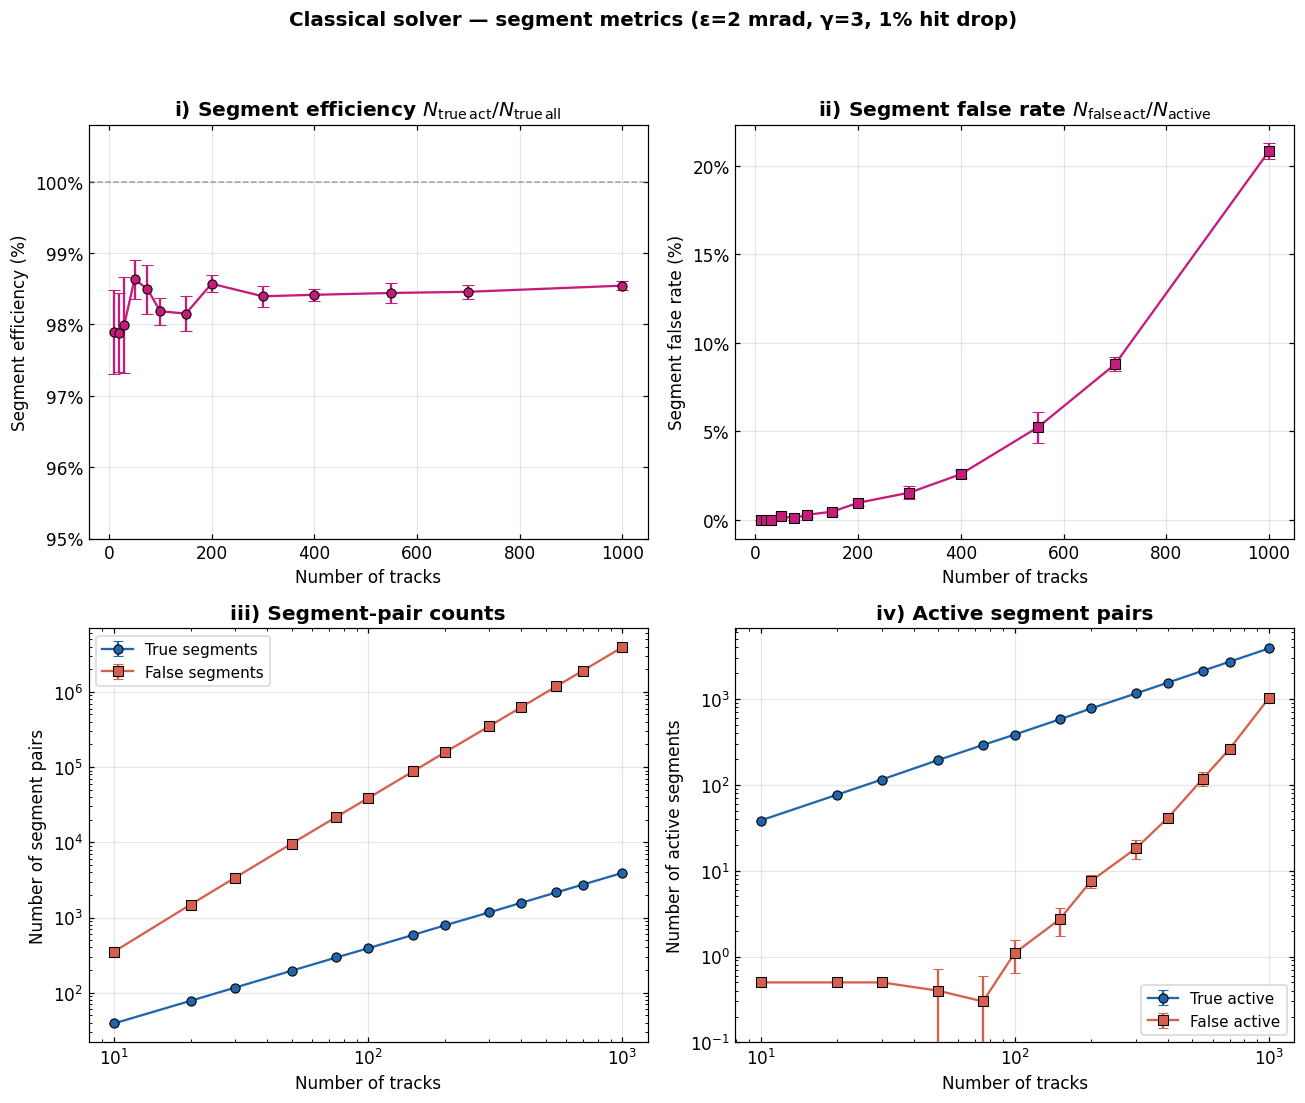

saved classical_2x2_g3_drop1pct (reps/point >= 5 )


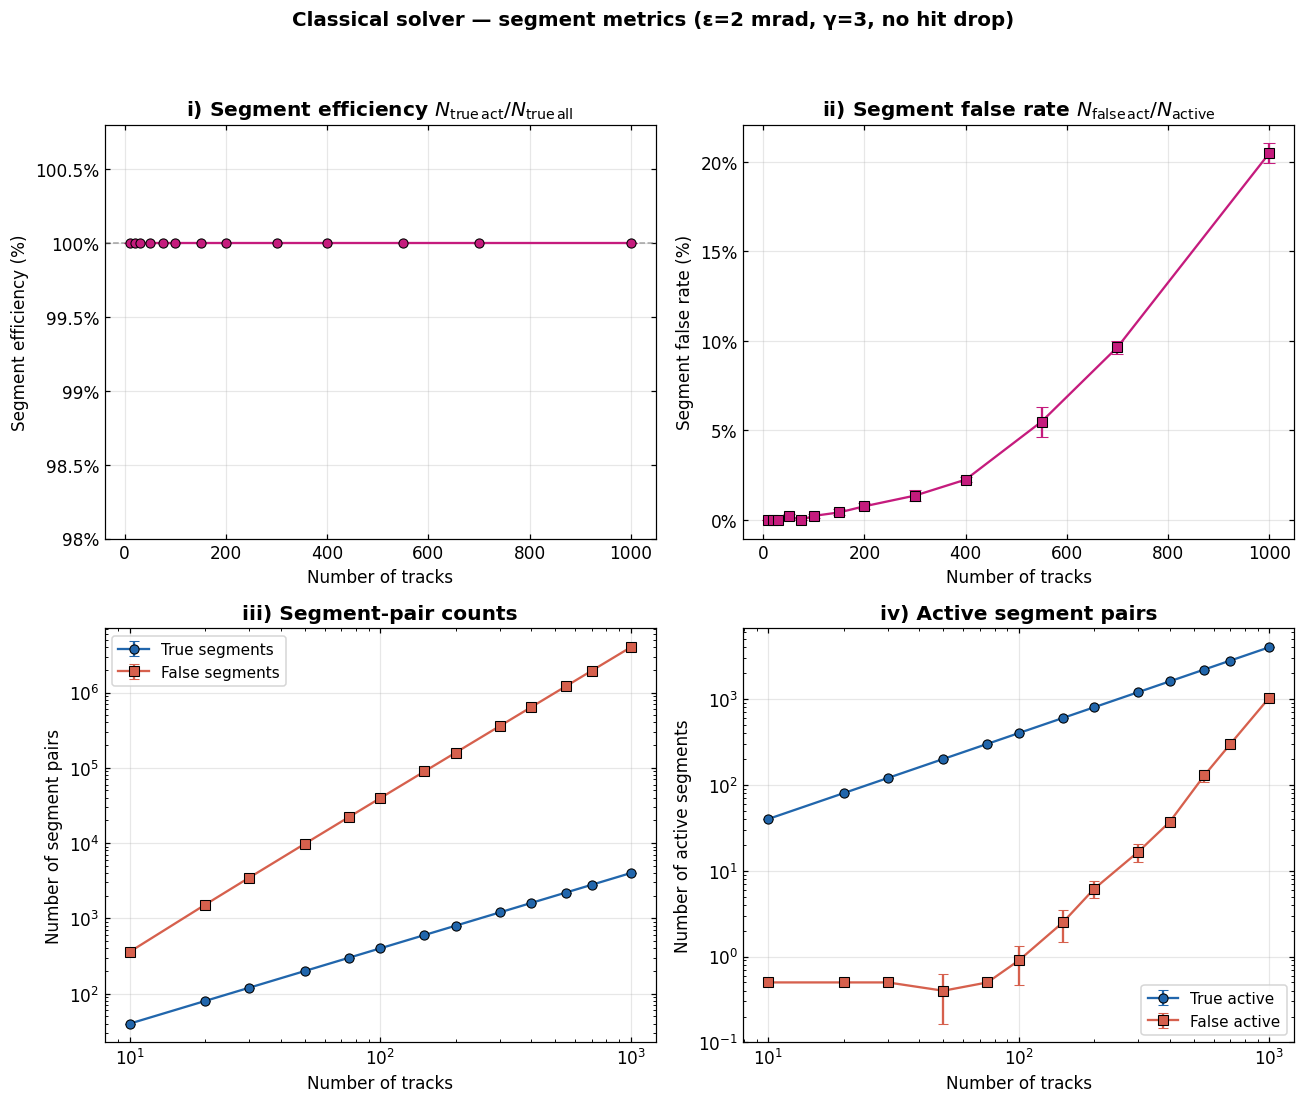

saved classical_2x2_g3_base (reps/point >= 5 )


In [4]:
if READY:
    plot_2x2(S.agg_by_ntrk(M, "classical", gamma=3.0, hit_ineff=0.01),
             r"Classical solver — segment metrics (ε=2 mrad, γ=3, 1% hit drop)",
             "classical_2x2_g3_drop1pct")
    plot_2x2(S.agg_by_ntrk(M, "classical", gamma=3.0, hit_ineff=0.0),
             r"Classical solver — segment metrics (ε=2 mrad, γ=3, no hit drop)",
             "classical_2x2_g3_base")

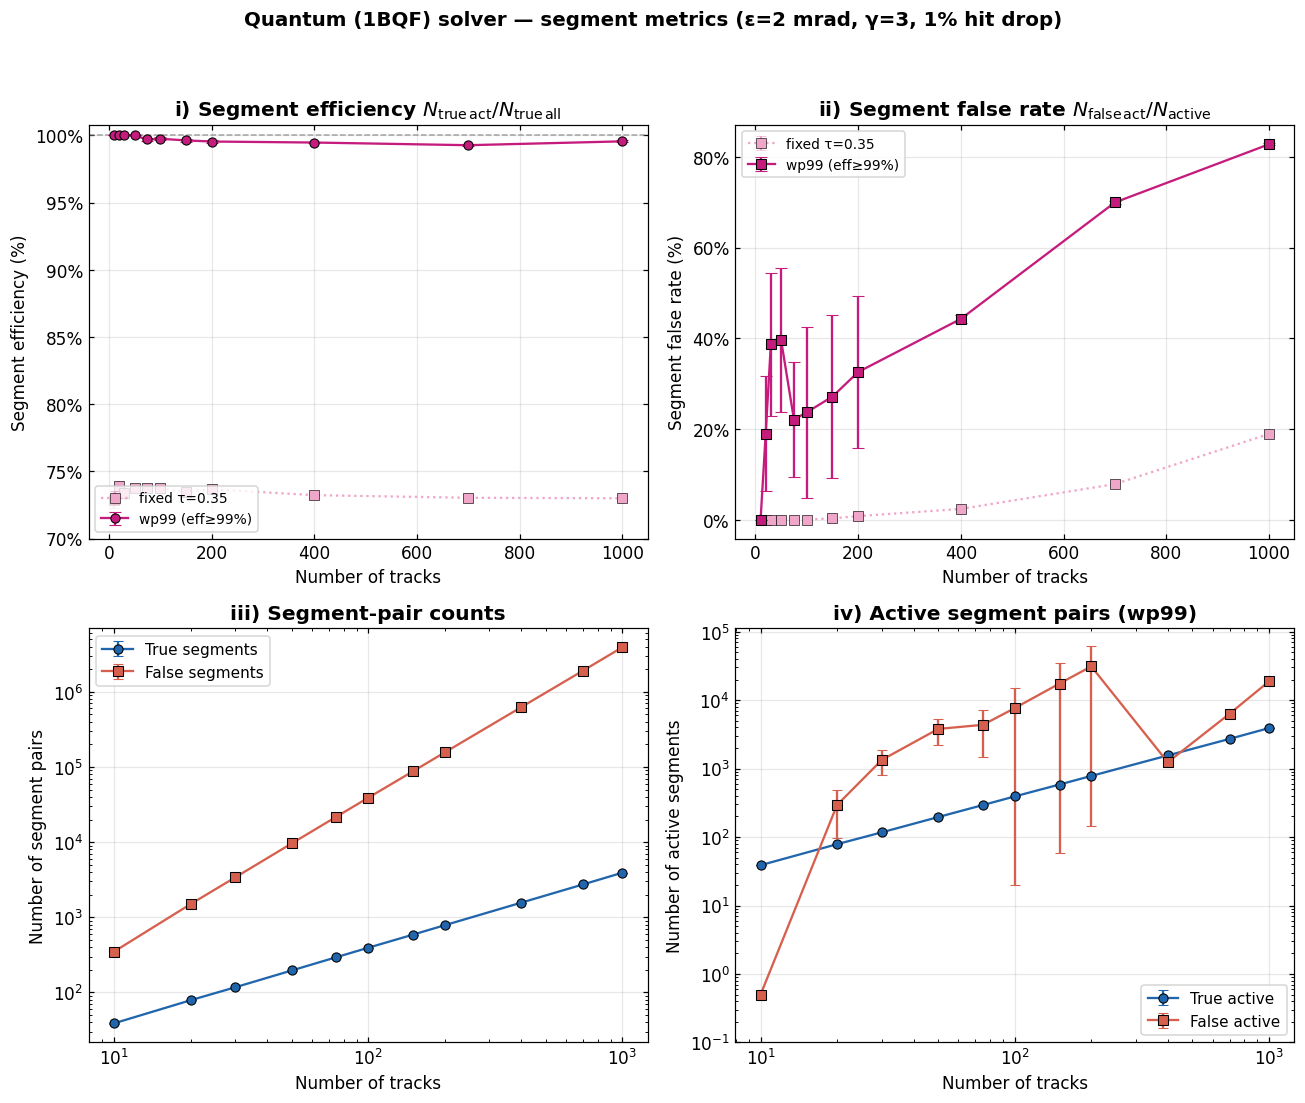

saved quantum_2x2_g3_drop1pct (reps/point >= 3 )


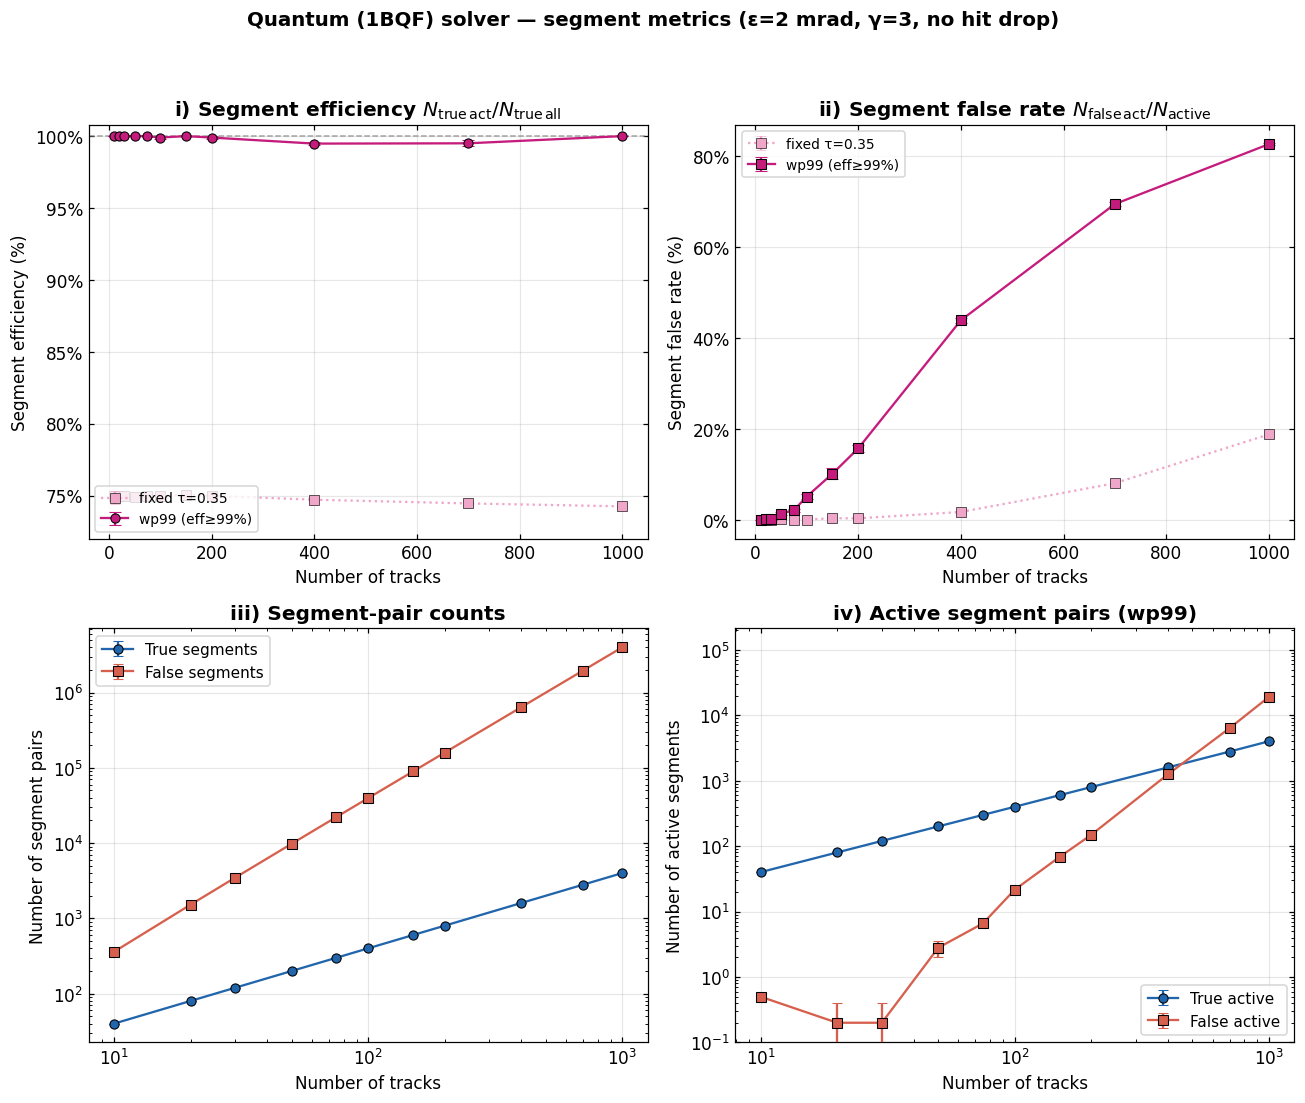

saved quantum_2x2_g3_base (reps/point >= 3 )
NOTE: quantum reps are few (3 at low n, 1 at n>=700) -> wide/zero error bars at high n.


In [5]:
if READY:
    plot_2x2(S.agg_by_ntrk(M, "quantum", gamma=3.0, hit_ineff=0.01),
             r"Quantum (1BQF) solver — segment metrics (ε=2 mrad, γ=3, 1% hit drop)",
             "quantum_2x2_g3_drop1pct", wp_headline=True)
    plot_2x2(S.agg_by_ntrk(M, "quantum", gamma=3.0, hit_ineff=0.0),
             r"Quantum (1BQF) solver — segment metrics (ε=2 mrad, γ=3, no hit drop)",
             "quantum_2x2_g3_base", wp_headline=True)
    print("NOTE: quantum reps are few (3 at low n, 1 at n>=700) -> wide/zero error bars at high n.")

## Companion — γ ∈ {1, 2, 3} overlay (efficiency & false rate, 1 % drop)

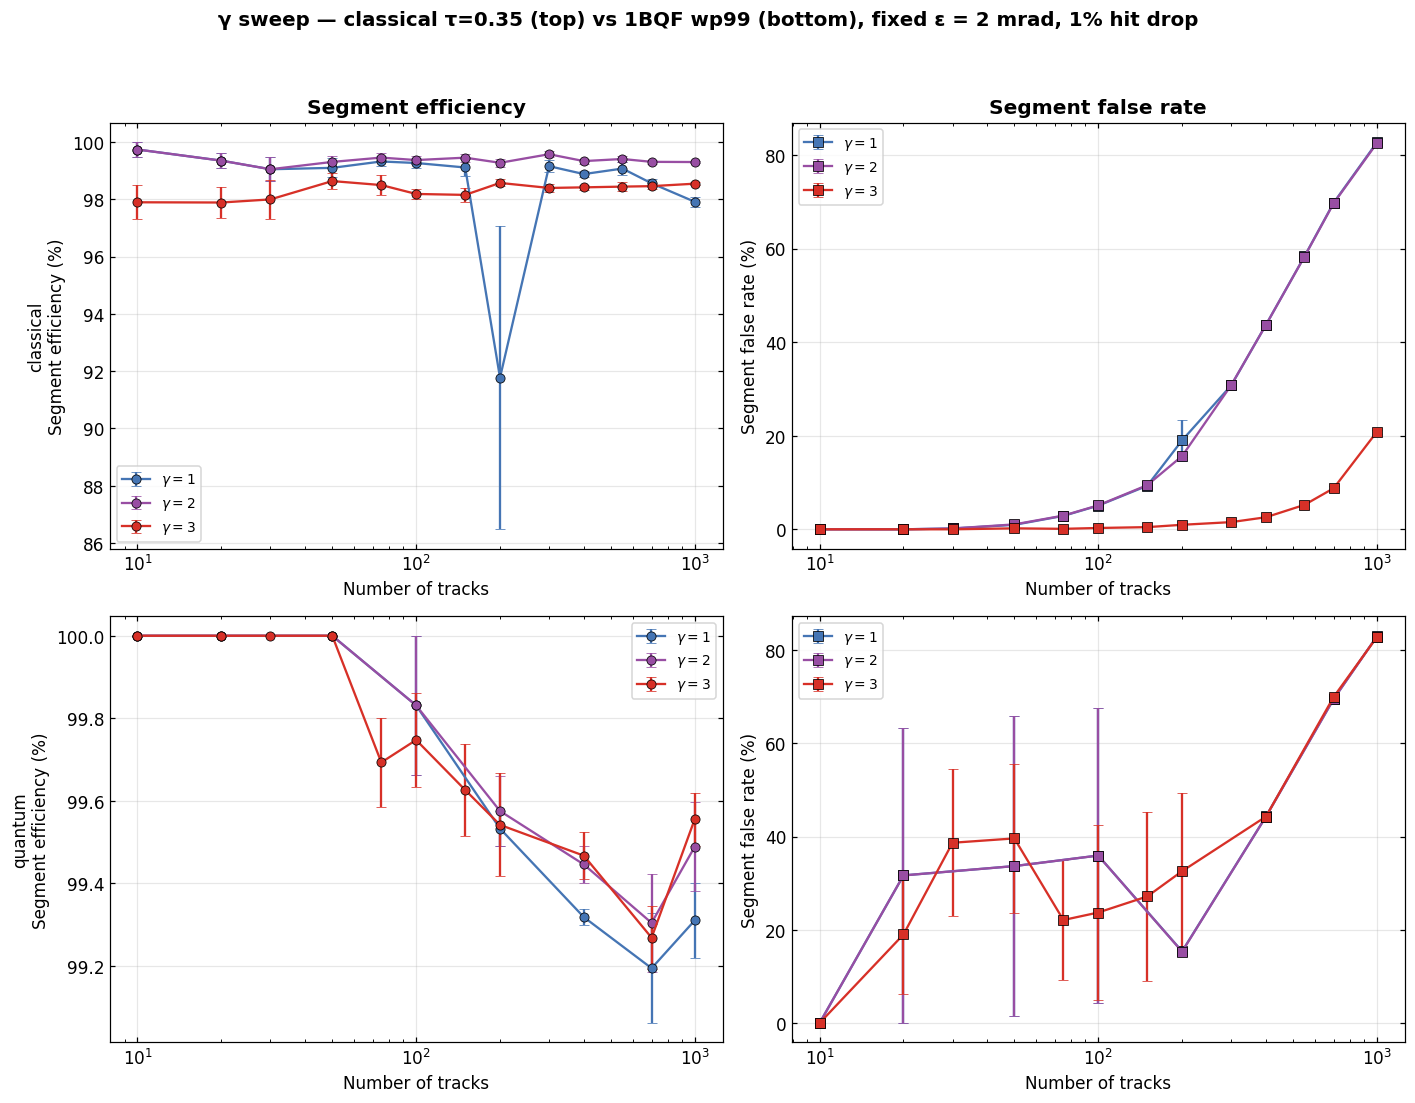

saved gamma_sweep_companion


In [6]:
if READY:
    GCOL = {1.0: "#4575b4", 2.0: "#984ea3", 3.0: "#d73027"}
    fig, ax = plt.subplots(2, 2, figsize=(13, 10))
    for si, solver in enumerate(["classical", "quantum"]):
        is_q = solver == "quantum"
        for g in (1.0, 2.0, 3.0):
            d = S.agg_by_ntrk(M, solver, gamma=g, hit_ineff=0.01)
            if not d:
                continue
            # classical at its fixed τ=0.35; 1BQF at the wp99 working point
            se = d.get("se_wp_m", d["se_m"]) if is_q else d["se_m"]
            see = d.get("se_wp_e", d["se_e"]) if is_q else d["se_e"]
            fr = d.get("fr_wp_m", d["fr_m"]) if is_q else d["fr_m"]
            fre = d.get("fr_wp_e", d["fr_e"]) if is_q else d["fr_e"]
            ax[si, 0].errorbar(d["tc"], se, yerr=see, fmt="o-",
                               color=GCOL[g], capsize=3, mec="k", mew=0.5,
                               label=fr"$\gamma={g:g}$")
            ax[si, 1].errorbar(d["tc"], fr, yerr=fre, fmt="s-",
                               color=GCOL[g], capsize=3, mec="k", mew=0.5,
                               label=fr"$\gamma={g:g}$")
        ax[si, 0].set_ylabel(f"{solver}\nSegment efficiency (%)")
        ax[si, 1].set_ylabel("Segment false rate (%)")
        for j in (0, 1):
            ax[si, j].set_xscale("log"); ax[si, j].set_xlabel("Number of tracks")
            ax[si, j].legend(fontsize=9)
            ax[si, j].tick_params(which="both", direction="in", top=True, right=True)
    ax[0, 0].set_title("Segment efficiency", fontweight="bold")
    ax[0, 1].set_title("Segment false rate", fontweight="bold")
    fig.suptitle(r"γ sweep — classical τ=0.35 (top) vs 1BQF wp99 (bottom), fixed ε = 2 mrad, 1% hit drop",
                 fontsize=13, fontweight="bold", y=1.00)
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    for ext, dpi in (("pdf", 600), ("png", 300)):
        fig.savefig(OUT / f"gamma_sweep_companion.{ext}", dpi=dpi,
                    bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved gamma_sweep_companion")

## Summary table (CSV export)

In [7]:
if READY:
    rows = []
    for solver in ["classical", "quantum"]:
        for g in (1.0, 2.0, 3.0):
            for hi in (0.0, 0.01):
                d = S.agg_by_ntrk(M, solver, gamma=g, hit_ineff=hi)
                if not d:
                    continue
                for i, n in enumerate(d["tc"]):
                    row = dict(solver=solver, gamma=g, hit_ineff=hi,
                               n_trk=int(n),
                               eff_fix_pct=round(d["se_m"][i], 3),
                               far_fix_pct=round(d["fr_m"][i], 3),
                               n_true=round(d["ntm"][i], 1),
                               n_false_all=round(d["nfm"][i], 1))
                    if "se_wp_m" in d:   # wp99 HEADLINE columns
                        row.update(eff_wp_pct=round(d["se_wp_m"][i], 3),
                                   eff_wp_sem=round(d["se_wp_e"][i], 3),
                                   far_wp_pct=round(d["fr_wp_m"][i], 3),
                                   far_wp_sem=round(d["fr_wp_e"][i], 3))
                    rows.append(row)
    tab = pd.DataFrame(rows)
    tab.to_csv(OUT / "segment_efficiency_summary.csv", index=False)
    print("wrote segment_efficiency_summary.csv  (", len(tab), "rows )")
    show = [c for c in ("solver","gamma","hit_ineff","n_trk","eff_fix_pct","far_fix_pct",
                        "eff_wp_pct","far_wp_pct") if c in tab.columns]
    display(tab[(tab.solver=="quantum") & (tab.gamma==3.0) & (tab.hit_ineff==0.01)][show])

wrote segment_efficiency_summary.csv  ( 132 rows )


,solver,gamma,hit_ineff,n_trk,eff_fix_pct,far_fix_pct,eff_wp_pct,far_wp_pct
121,quantum,3.0,0.01,10,72.895,0.000,100.000,0.000
122,quantum,3.0,0.01,20,73.937,0.000,100.000,19.000
123,quantum,3.0,0.01,30,73.431,0.000,100.000,38.667
124,quantum,3.0,0.01,50,73.802,0.000,100.000,39.599
125,quantum,3.0,0.01,75,73.745,0.046,99.693,22.100
126,quantum,3.0,0.01,100,73.732,0.067,99.747,23.707
127,quantum,3.0,0.01,150,73.474,0.322,99.626,27.158
128,quantum,3.0,0.01,200,73.671,0.815,99.542,32.573
129,quantum,3.0,0.01,400,73.235,2.405,99.467,44.281
130,quantum,3.0,0.01,700,73.039,7.873,99.268,69.945
